### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, 
    RocCurveDisplay
)

from xgboost import XGBClassifier

### Step 1: Data Loading

In [2]:
circuits = pd.read_csv("circuits.csv")
drivers = pd.read_csv("drivers.csv")
races = pd.read_csv("races.csv")
results = pd.read_csv("results.csv")
qualifying = pd.read_csv("qualifying.csv")
constructors = pd.read_csv("constructors.csv")

### Step 2: Variable selction and Renaming  

In [3]:
drivers = drivers[["driverId", "forename", "surname", "nationality"]].copy()
drivers["driver"] = drivers["forename"] + " " + drivers["surname"]
drivers = drivers.drop(columns=["forename", "surname"])
drivers = drivers.rename(columns={"nationality": "driver_nationality"})

races = races[["raceId", "year", "name", "circuitId", "date"]].copy()
races = races.rename(columns={"year": "season", "name": "race"})

circuits = circuits[["circuitId", "name", "location", "country"]].copy()
circuits = circuits.rename(columns={
    "name": "circuit_name",
    "location": "circuit_location",
    "country": "circuit_country"
})

results = results[[
    "raceId",
    "driverId",
    "constructorId",
    "grid",
    "position",
    "points",
    "laps",
    "fastestLapSpeed"
]].copy()

results = results.rename(columns={
    "grid": "grid_position",
    "position": "finish_position",
    "fastestLapSpeed": "fastest_lap_speed"
})

constructors = constructors[["constructorId", "name", "nationality"]].copy()
constructors = constructors.rename(columns={
    "name": "constructor",
    "nationality": "constructor_nationality"
})

### Step 3: Merge

In [4]:
df = results.merge(races, on="raceId", how="left")
df = df.merge(circuits, on="circuitId", how="left")
df = df.merge(drivers, on="driverId", how="left")
df = df.merge(constructors, on="constructorId", how="left")
print("Results rows:", results.shape)
print("Merged rows:", df.shape)


df.isnull().sum()

Results rows: (26759, 8)
Merged rows: (26759, 19)


raceId                     0
driverId                   0
constructorId              0
grid_position              0
finish_position            0
points                     0
laps                       0
fastest_lap_speed          0
season                     0
race                       0
circuitId                  0
date                       0
circuit_name               0
circuit_location           0
circuit_country            0
driver_nationality         0
driver                     0
constructor                0
constructor_nationality    0
dtype: int64

### Step 4: Column Selection

    

In [5]:
df = df[[
    "season",
    "date",
    "race",
    "driverId",
    "constructorId",
    "driver",
    "driver_nationality",
    "constructor",
    "constructor_nationality",
    "grid_position",
    "finish_position",
    "points",
    "laps",
    "fastest_lap_speed"
]].copy()

In [6]:
df.head()


,season,date,race,driverId,constructorId,driver,driver_nationality,constructor,constructor_nationality,grid_position,finish_position,points,laps,fastest_lap_speed
0,2008,2008-03-16,Australian Grand Prix,1,1,Lewis Hamilton,British,McLaren,British,1,1,10.0,58,218.300
1,2008,2008-03-16,Australian Grand Prix,2,2,Nick Heidfeld,German,BMW Sauber,German,5,2,8.0,58,217.586
2,2008,2008-03-16,Australian Grand Prix,3,3,Nico Rosberg,German,Williams,British,7,3,6.0,58,216.719
3,2008,2008-03-16,Australian Grand Prix,4,4,Fernando Alonso,Spanish,Renault,French,11,4,5.0,58,215.464
4,2008,2008-03-16,Australian Grand Prix,5,1,Heikki Kovalainen,Finnish,McLaren,British,3,5,4.0,58,218.385


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   season                   26759 non-null  int64  
 1   date                     26759 non-null  object 
 2   race                     26759 non-null  object 
 3   driverId                 26759 non-null  int64  
 4   constructorId            26759 non-null  int64  
 5   driver                   26759 non-null  object 
 6   driver_nationality       26759 non-null  object 
 7   constructor              26759 non-null  object 
 8   constructor_nationality  26759 non-null  object 
 9   grid_position            26759 non-null  int64  
 10  finish_position          26759 non-null  object 
 11  points                   26759 non-null  float64
 12  laps                     26759 non-null  int64  
 13  fastest_lap_speed        26759 non-null  object 
dtypes: float64(1), int64(5

season                     0
date                       0
race                       0
driverId                   0
constructorId              0
driver                     0
driver_nationality         0
constructor                0
constructor_nationality    0
grid_position              0
finish_position            0
points                     0
laps                       0
fastest_lap_speed          0
dtype: int64

### Step 5: Clean Data

In [8]:
df["dnf"] = pd.to_numeric(df["finish_position"], errors="coerce").isna().astype(int)

In [9]:
#Fastest lap 
df["fastest_lap_speed"] = df["fastest_lap_speed"].replace(r"\N", np.nan)
df["fastest_lap_speed"] = pd.to_numeric(df["fastest_lap_speed"], errors="coerce")
df["fastest_lap_speed"] = df["fastest_lap_speed"].fillna(df["fastest_lap_speed"].median())


In [10]:
#Finish Position

df["finish_position"] = df["finish_position"].replace(r"\N", np.nan)
df["finish_position"] = pd.to_numeric(df["finish_position"], errors="coerce")
df = df.dropna(subset=["finish_position"])
df["finish_position"] = df["finish_position"].astype(int)

In [11]:
#Grid Position

df["grid_position"] = pd.to_numeric(df["grid_position"], errors="coerce")
df.loc[df["grid_position"] == 0, "grid_position"] = np.nan
df["grid_position"] = df["grid_position"].fillna(df["grid_position"].median())
df["grid_position"] = df["grid_position"].astype(int)


In [12]:
#Laps

df["laps"] = pd.to_numeric(df["laps"], errors="coerce")
df = df[df["laps"] > 0]


In [13]:
df = df.drop_duplicates()

In [14]:

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["date", "race"]).copy()

df["driver_avg_finish_last5"] = (
    df.groupby("driverId")["finish_position"]
      .transform(lambda s: s.shift(1).rolling(window=5, min_periods=1).mean())
)

df["constructor_avg_finish_last5"] = (
    df.groupby("constructorId")["finish_position"]
      .transform(lambda s: s.shift(1).rolling(window=5, min_periods=1).mean())
)

df["driver_dnf_rate_last5"] = (
    df.groupby("driverId")["dnf"]
      .transform(lambda s: s.shift(1).rolling(window=5, min_periods=1).mean())
)


df["driver_avg_finish_last5"] = df["driver_avg_finish_last5"].fillna(df["finish_position"].median())
df["constructor_avg_finish_last5"] = df["constructor_avg_finish_last5"].fillna(df["finish_position"].median())
df["driver_dnf_rate_last5"] = df["driver_dnf_rate_last5"].fillna(0)

### Step 6: Target Variable  

In [15]:
df["podium"] = (df["finish_position"] <= 3).astype(int)
df["podium"].value_counts()
df["podium"].value_counts(normalize=True)

podium
0    0.785145
1    0.214855
Name: proportion, dtype: float64

In [16]:
df = df.drop(columns=["finish_position", "points", "dnf"])

### Step 7: Feature Engineering

In [17]:
df["front_row_start"] = (df["grid_position"] <= 2).astype(int)
df["top5_start"] = (df["grid_position"] <= 5).astype(int)
df["top10_start"] = (df["grid_position"] <= 10).astype(int)

In [18]:
categorical_cols = [
    "race",
    "circuit_name",
    "circuit_location",
    "circuit_country",
    "driver_nationality",
    "constructor",
    "constructor_nationality"
]


### Step 8: Final Modelling Dataset 

In [19]:

keep_cols = [
    "season",
    "grid_position",
    "front_row_start",
    "top5_start",
    "top10_start",
    "driver_avg_finish_last5",
    "constructor_avg_finish_last5",
    "podium"
]

df_small = df[keep_cols].copy()
df_small = df_small[df_small["season"] >= 2010]

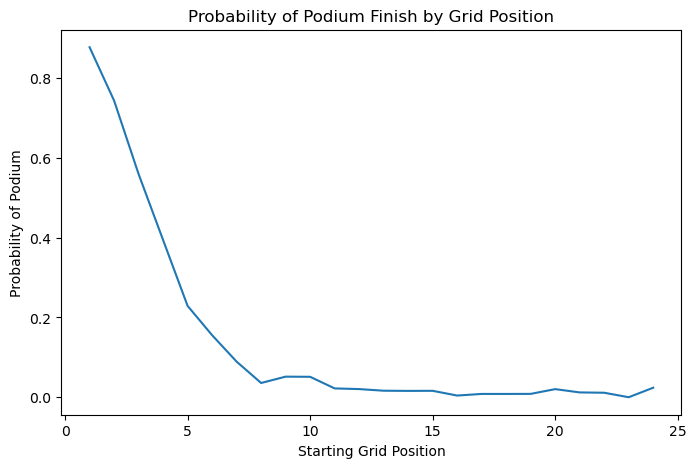

In [20]:
podium_prob = df_small.groupby("grid_position")["podium"].mean()

plt.figure(figsize=(8,5))
sns.lineplot(x=podium_prob.index, y=podium_prob.values)

plt.title("Probability of Podium Finish by Grid Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Probability of Podium")

plt.show()

### Step 9: Dataset Inspection (EDA)

In [21]:
df_small.head()

,season,grid_position,front_row_start,top5_start,top10_start,driver_avg_finish_last5,constructor_avg_finish_last5,podium
20320,2010,3,0,1,1,7.6,11.4,1
20321,2010,2,1,1,1,4.6,9.2,1
20322,2010,4,0,1,1,4.2,7.4,1
20323,2010,1,1,1,1,3.6,5.0,0
20324,2010,5,0,1,1,9.8,2.4,0


In [22]:
df_small.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5397 entries, 20320 to 26755
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   season                        5397 non-null   int64  
 1   grid_position                 5397 non-null   int64  
 2   front_row_start               5397 non-null   int64  
 3   top5_start                    5397 non-null   int64  
 4   top10_start                   5397 non-null   int64  
 5   driver_avg_finish_last5       5397 non-null   float64
 6   constructor_avg_finish_last5  5397 non-null   float64
 7   podium                        5397 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 379.5 KB


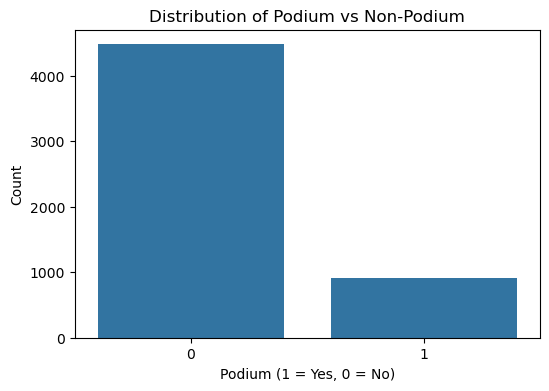

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_small, x="podium")
plt.title("Distribution of Podium vs Non-Podium")
plt.xlabel("Podium (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

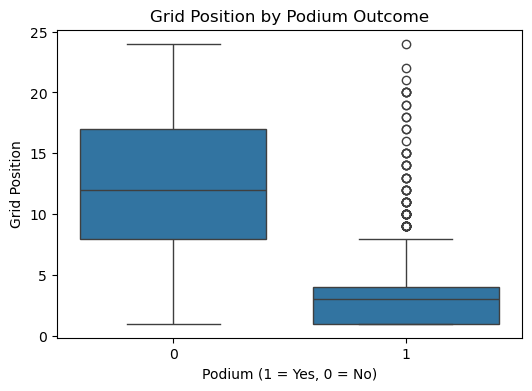

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_small, x="podium", y="grid_position")
plt.title("Grid Position by Podium Outcome")
plt.xlabel("Podium (1 = Yes, 0 = No)")
plt.ylabel("Grid Position")
plt.show()

### Step 10: Train/Test Split

In [25]:

train = df_small[(df_small["season"] >= 2010) & (df_small["season"] <= 2020)]
test = df_small[df_small["season"] > 2020]

X_train = train.drop("podium", axis=1)
y_train = train["podium"]

X_test = test.drop("podium", axis=1)
y_test = test["podium"]

In [26]:

test_meta = df.loc[test.index, ["season", "race", "driver", "constructor", "grid_position", "podium"]].copy()

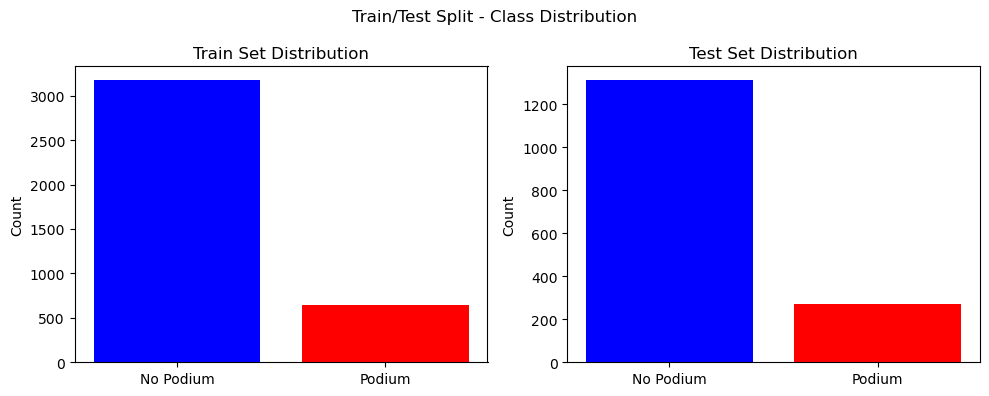

Train size: 3816 rows (70.7%)
Test size: 1581 rows (29.3%)


In [27]:
train_counts = y_train.value_counts()
test_counts = y_test.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].bar(["No Podium", "Podium"], train_counts, color=["blue", "red"])
axes[0].set_title("Train Set Distribution")
axes[0].set_ylabel("Count")

axes[1].bar(["No Podium", "Podium"], test_counts, color=["blue", "red"])
axes[1].set_title("Test Set Distribution")
axes[1].set_ylabel("Count")

plt.suptitle("Train/Test Split - Class Distribution")
plt.tight_layout()
plt.show()

print(f"Train size: {len(y_train)} rows ({len(y_train)/len(df_small)*100:.1f}%)")
print(f"Test size: {len(y_test)} rows ({len(y_test)/len(df_small)*100:.1f}%)")



### Step 11: Logistic Regression

In [28]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

In [29]:

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Accuracy: 0.8589500316255535
Precision: 0.5545243619489559
Recall: 0.8851851851851852
F1: 0.68188302425107
ROC-AUC: 0.9382829053309603


### Step 12: Random Forest

In [30]:

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth= None,
    random_state=42,
    min_samples_split=5,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.894370651486401
Precision: 0.6794425087108014
Recall: 0.7222222222222222
F1: 0.7001795332136446
ROC-AUC: 0.921640251998757


### Step 13: Gradient Boosting 

In [32]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

gb_model = GradientBoostingClassifier(
  learning_rate=0.05,
  n_estimators=300,
  max_depth=3,
  random_state=42
)

gb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Accuracy: 0.8513598987982289
Precision: 0.5427872860635696
Recall: 0.8222222222222222
F1: 0.6539027982326951
ROC-AUC: 0.9139630477159081


### Step 14: XGBoost

In [34]:

n_pos = sum(y_train == 1)
n_neg = sum(y_train == 0)

scale_pos_weight = n_neg / n_pos
print(scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss",
    subsample=0.8,
    colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

4.916279069767442


In [35]:

xgb_predictions = test_meta.copy()
xgb_predictions["predicted_podium"] = y_pred_xgb
xgb_predictions["podium_probability"] = y_prob_xgb


xgb_predictions = xgb_predictions.sort_values(
    by=["season", "race", "podium_probability"],
    ascending=[True, True, False]
)


xgb_predictions["predicted_rank_within_race"] = (
    xgb_predictions.groupby(["season", "race"])["podium_probability"]
    .rank(method="first", ascending=False)
)

xgb_predictions["predicted_top3"] = (
    xgb_predictions["predicted_rank_within_race"] <= 3
).astype(int)

xgb_predictions.tail(20)

,season,race,driver,constructor,grid_position,podium,predicted_podium,podium_probability,predicted_rank_within_race,predicted_top3
26693,2024,São Paulo Grand Prix,Guanyu Zhou,Sauber,19,0,0,0.000317,15.0,0
26642,2024,United States Grand Prix,Lando Norris,McLaren,1,0,1,0.966587,1.0,1
26641,2024,United States Grand Prix,Max Verstappen,Red Bull,2,1,1,0.934298,2.0,1
26639,2024,United States Grand Prix,Charles Leclerc,Ferrari,4,1,1,0.793372,3.0,1
26640,2024,United States Grand Prix,Carlos Sainz,Ferrari,3,1,1,0.767688,4.0,0
26643,2024,United States Grand Prix,Oscar Piastri,McLaren,5,0,1,0.736627,5.0,0
26644,2024,United States Grand Prix,George Russell,Mercedes,20,0,1,0.606348,6.0,0
26651,2024,United States Grand Prix,Fernando Alonso,Aston Martin,7,0,0,0.076841,7.0,0
26650,2024,United States Grand Prix,Pierre Gasly,Alpine F1 Team,6,0,0,0.073582,8.0,0
26645,2024,United States Grand Prix,Sergio Pérez,Red Bull,9,0,0,0.062428,9.0,0


In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.866540164452878
Precision: 0.5750636132315522
Recall: 0.837037037037037
F1: 0.6817496229260935
ROC-AUC: 0.9275291691386276


### Step 15: Model Comparison 

In [37]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.858950,0.554524,0.885185,0.681883,0.938283
1,Random Forest,0.894371,0.679443,0.722222,0.700180,0.921640
2,Gradient Boosting,0.851360,0.542787,0.822222,0.653903,0.913963
3,XGBoost,0.866540,0.575064,0.837037,0.681750,0.927529


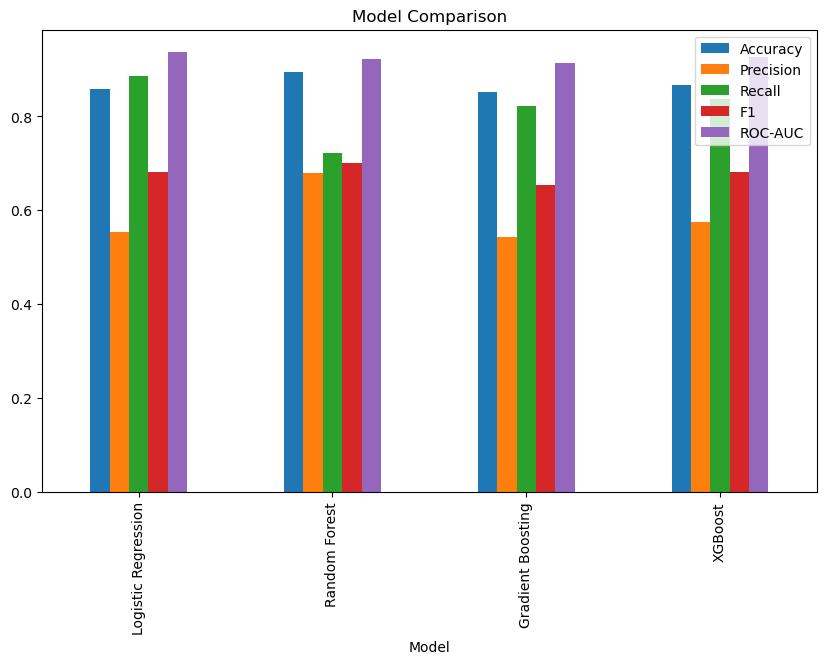

In [38]:
results.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.show()

In [39]:
xgb_importance = xgb_model.feature_importances_

xgb_feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_importance
}).sort_values("importance", ascending=False)

xgb_feat_imp

,feature,importance
3,top5_start,0.614296
1,grid_position,0.157620
2,front_row_start,0.087784
5,driver_avg_finish_last5,0.052599
4,top10_start,0.038391
6,constructor_avg_finish_last5,0.029010
0,season,0.020300


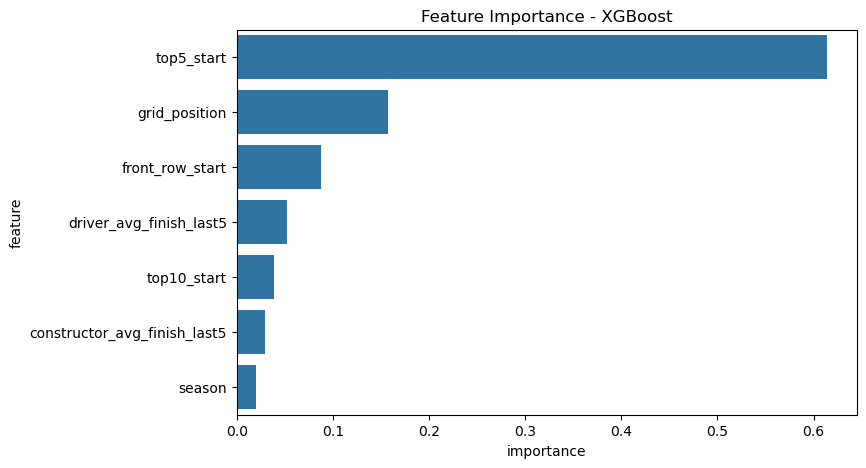

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(data=xgb_feat_imp, x="importance", y="feature")
plt.title("Feature Importance - XGBoost")
plt.show()

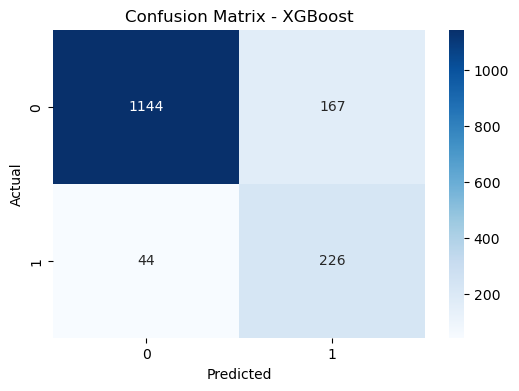

In [41]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

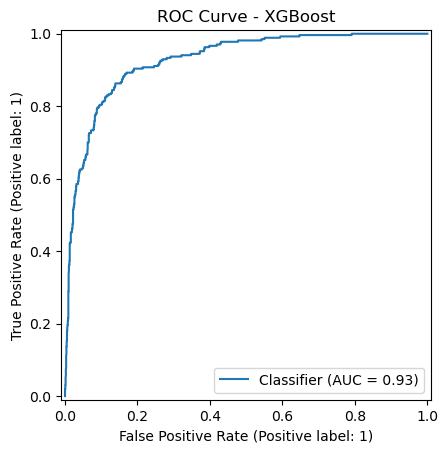

In [42]:
RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.title("ROC Curve - XGBoost")
plt.show()

In [44]:

tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring="roc_auc")
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")



Logistic Regression: 0.9373 ± 0.0149
Random Forest: 0.9255 ± 0.0141
Gradient Boosting: 0.9244 ± 0.0240
XGBoost: 0.9241 ± 0.0248
